In [1]:
import numpy as np


In [2]:
!pip install -Uq pymcel

In [3]:
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [4]:
import matplotlib.pyplot as plt

In [5]:
# Obtener posiciones y velocidades del Sol y Júpiter respecto al SSB en una fecha dada
import numpy as np

fecha = '2026-2-26'

# Sol (id='10')
tabla_sol, jd_sol, X_sol = pc.consulta_horizons(id='10', location='@SSB', epochs=fecha)
# Júpiter (id='599')
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(id='599', location='@SSB', epochs=fecha)

# X_sol y X_jup contienen [x, y, z, vx, vy, vz] en metros y metros/segundo
pos_sol = X_sol[0:3]
vel_sol = X_sol[3:6]
pos_jup = X_jup[0:3]
vel_jup = X_jup[3:6]

print(f"Posición del Sol: {pos_sol} m")
print(f"Velocidad del Sol: {vel_sol} m/s")
print(f"Posición de Júpiter: {pos_jup} m")
print(f"Velocidad de Júpiter: {vel_jup} m/s")

Posición del Sol: [-3.99267884e+08 -8.24090450e+08  1.85429947e+07] m
Velocidad del Sol: [12.21082288  1.23932702 -0.24260412] m/s
Posición de Júpiter: [-3.13499452e+11  7.16531814e+11  4.04380354e+09] m
Velocidad de Júpiter: [-12126.94590106  -4617.33467629    290.53119391] m/s


## Órbitas baricéntricas del sistema solar

En esta sección no integramos explícitamente las ecuaciones de movimiento,
sino que usamos efemérides de JPL Horizons (a través de `pymcel`) para obtener
las trayectorias baricéntricas de los cuerpos del sistema solar.

Denotamos por $t_k$ una malla de épocas en días julianos (JD) y por
$\mathbf r_i(t_k) = (x_i, y_i, z_i)$ la posición del cuerpo $i$ (Sol, planetas)
respecto al baricentro del sistema solar (SSB). Los vectores se obtienen de Horizons en
un sistema de referencia baricéntrico y en unidades SI (metros).

A nivel conceptual, estamos muestreando la solución $\mathbf r_i(t)$ ya calculada por Horizons,
y luego representamos sus proyecciones en el plano $x$–$y$ reescaladas a unidades astronómicas (UA):

$$ 1\text{UA} = 1.495978707 	imes 10^{11}\,\text{m}. $$

La siguiente celda de código construye el intervalo temporal, consulta las efemérides
para cada cuerpo $(i)$ en bloques de épocas (para evitar URIs demasiado largas) y
grafica las órbitas baricéntricas en el plano eclíptico $x$–$y$.

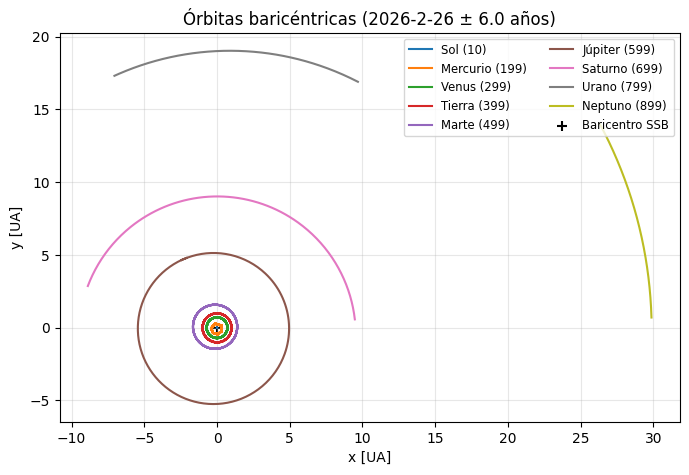

In [9]:
# Trayectorias baricéntricas de los planetas con Horizons + pyplot
# ---------------------------------------------------------------
# En este bloque NO integramos ecuaciones de movimiento.
# Usamos efemérides de JPL Horizons (vía pymcel) para obtener:
#   r_i(t_k) = (x, y, z)_i(t_k)  en unidades SI (m)
# donde:
#   - i recorre los cuerpos (Sol, planetas)
#   - t_k son épocas en días julianos (JD)
#   - el sistema de referencia es baricéntrico (@SSB).
# Luego reescalamos a unidades astronómicas (1 UA = 1.495978707e11 m)
# y proyectamos en el plano (x, y) para visualizar las órbitas.

# Definición del intervalo temporal en días (por ejemplo, 12 años)
n_puntos = 300             # número de muestras temporales
años = 12                  # intervalo total en años civiles
t0 = jd_sol                # JD central tomado de la consulta previa al Sol
t1 = jd_sol + años * 365.25
epocas = np.linspace(t0, t1, n_puntos)

# IDs de Horizons de algunos cuerpos del sistema solar
cuerpos = {
    'Sol (10)': '10',
    'Mercurio (199)': '199',
    'Venus (299)': '299',
    'Tierra (399)': '399',
    'Marte (499)': '499',
    'Júpiter (599)': '599',
    'Saturno (699)': '699',
    'Urano (799)': '799',
    'Neptuno (899)': '899',
}

# Conversión de unidades: 1 UA en metros (unidades SI)
AU = 1.495978707e11  # [m]

fig, ax = plt.subplots(figsize=(8, 8))  # figura cuadrada para órbitas

for nombre, hid in cuerpos.items():
    # Para cada cuerpo pedimos r_i(t_k) en bloques de épocas para evitar URIs muy largas.
    # Matemáticamente solo estamos muestreando la solución ya tabulada por Horizons.
    X_list = []        # almacenará matrices [N_batch x 6] con (x,y,z,vx,vy,vz)
    jd_list = []       # almacenará los JD devueltos en cada bloque
    batch_size = 50    # número de épocas por consulta HTTP
    for i in range(0, len(epocas), batch_size):
        ep_batch = epocas[i:i+batch_size]  # subconjunto de épocas (JD)
        tabla, jd_arr, X_batch = pc.consulta_horizons(id=hid, location='@SSB', epochs=ep_batch)
        jd_list.append(jd_arr)
        X_list.append(X_batch)

    # Concatenamos todos los bloques para reconstruir la trayectoria completa
    jd_arr = np.concatenate(jd_list)   # tiempos en JD (no usados directamente en la gráfica)
    X = np.vstack(X_list)              # matriz completa [n_puntos x 6]
    # Extraemos solo el vector posición r = (x, y, z) en unidades SI (m)
    r = X[:, :3]
    # Representamos la órbita proyectada en el plano (x, y) y reescalada a UA
    ax.plot(r[:, 0] / AU, r[:, 1] / AU, label=nombre)

# El baricentro del sistema solar (SSB) está en el origen (0, 0) en este sistema de referencia
ax.scatter(0, 0, c='k', marker='+', s=50, label='Baricentro SSB')

ax.set_aspect('equal', 'box')
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.set_title(f'Órbitas baricéntricas ({fecha} ± {años/2} años)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize='small', ncol=2)

plt.show()

## Sub-sistema Sol–Júpiter en el marco baricéntrico

Aquí nos restringimos al sub-sistema formado solo por el Sol y Júpiter,
pero seguimos usando efemérides de Horizons para obtener las posiciones
$\mathbf r_\odot(t_k)$ y $\mathbf r_{\mathrm J}(t_k)$ respecto al baricentro SSB.

El objetivo es visualizar la *danza* Sol–Júpiter alrededor del baricentro comum,
mostrando cómo ambos cuerpos describen órbitas baricéntricas en el plano eclíptico.

En términos de vectores de posición:
$$ \mathbf r_\odot(t_k) = (x_\odot, y_\odot, z_\odot), \qquad \mathbf r_{\mathrm J}(t_k) = (x_{\mathrm J}, y_{\mathrm J}, z_{\mathrm J}), $$
y el baricentro del sistema Sol–Júpiter coincide con el origen en este sistema de referencia.

La siguiente celda de código construye un intervalo temporal centrado en la fecha `fecha`,
consulta las efemérides solo para estos dos cuerpos y grafica sus trayectorias en el plano $x$–$y$
en unidades astronómicas (UA).

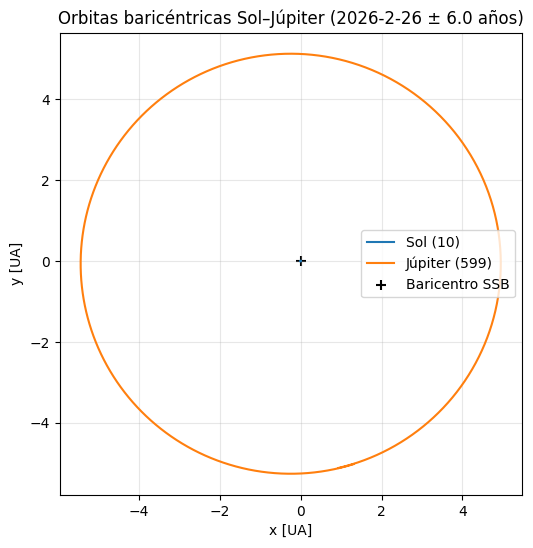

In [10]:
# Órbitas baricéntricas Sol–Júpiter (versión simple)
# ---------------------------------------------------
# De nuevo, NO resolvemos aquí el problema de dos cuerpos.
# Usamos directamente la solución tabulada por Horizons:
#   r_Sol(t_k), r_Jup(t_k) respecto al baricentro SSB.
# Esto permite visualizar la danza Sol–Júpiter alrededor del baricentro.

# Muestreo temporal centrado en la fecha 'fecha' (± años_sj/2)
n_puntos_sj = 200                  # número de puntos de la trayectoria
años_sj = 12                       # intervalo total en años
t0_sj = jd_sol - (años_sj * 365.25) / 2  # JD inicial
t1_sj = jd_sol + (años_sj * 365.25) / 2  # JD final
epocas_sj = np.linspace(t0_sj, t1_sj, n_puntos_sj)

# Solo consideramos dos cuerpos: Sol y Júpiter
cuerpos_sj = {
    'Sol (10)': '10',
    'Júpiter (599)': '599',
}

fig, ax = plt.subplots(figsize=(6, 6))

for nombre, hid in cuerpos_sj.items():
    # Para cada cuerpo construimos su trayectoria baricéntrica r_i(t_k)
    X_list = []
    batch_size = 50   # número de épocas por consulta
    for i in range(0, len(epocas_sj), batch_size):
        ep_batch = epocas_sj[i:i+batch_size]
        tabla, jd_arr, X_batch = pc.consulta_horizons(id=hid, location='@SSB', epochs=ep_batch)
        X_list.append(X_batch)

    # X tiene filas [x, y, z, vx, vy, vz] en unidades SI
    X = np.vstack(X_list)
    r = X[:, :3]  # nos quedamos solo con el vector posición r(t_k)
    ax.plot(r[:, 0] / AU, r[:, 1] / AU, label=nombre)

# El baricentro SSB está en el origen de coordenadas (0, 0)
ax.scatter(0, 0, c='k', marker='+', s=50, label='Baricentro SSB')
ax.set_aspect('equal', 'box')
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.set_title(f'Orbitas baricéntricas Sol–Júpiter ({fecha} ± {años_sj/2} años)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## Problema de tres cuerpos Sol–Tierra–Luna (formulación continua)

Modelamos el sistema Sol–Tierra–Luna como tres masas puntuales que interaccionan
gravitacionalmente en el espacio tridimensional. Denotamos por $\mathbf r_i(t)$ y
$\mathbf v_i(t)$ las posiciones y velocidades de cada cuerpo $i \in \{L, T, S\}$:

- $i = L$ : Luna
- $i = T$ : Tierra
- $i = S$ : Sol.

Usamos los parámetros gravitacionales $\mu_i = G M_i$ proporcionados por `pymcel`
en unidades SI. Las ecuaciones de movimiento (Newtónicas) para cada cuerpo son:

$$ \ddot{\mathbf r}_i = - \sum_{j \neq i} \mu_j \frac{\mathbf r_i - \mathbf r_j}{\lVert \mathbf r_i - \mathbf r_j \rVert^3}. $$

En particular, para la Luna ($L$), la Tierra ($T$) y el Sol ($S$):

\begin{align*}
\ddot{\mathbf r}_L &= -\mu_S \dfrac{\mathbf r_L - \mathbf r_S}{\lVert \mathbf r_L - \mathbf r_S \rVert^3}
,
,
,
,
,
,

: 
,
: {
: 

: [
,
,
,
,
,
,
,
,
,
,
,
20
,
,
,
,
,
,
3
,
,
3
,
,
3
,
,
    Sistema de EDOs de primer orden para el problema de tres cuerpos
    Sol–Tierra–Luna en coordenadas cartesianas (unidades SI).

    Y = (r_L, r_T, r_S, v_L, v_T, v_S) con cada vector en R^3.
    Ecuaciones utilizadas:
      d r_i / dt = v_i
      d v_i / dt = - sum_{j != i} mu_j (r_i - r_j) / |r_i - r_j|^3
    """
    r_L = Y[0:3]
    r_T = Y[3:6]
    r_S = Y[6:9]
    v_L = Y[9:12]
    v_T = Y[12:15]
    v_S = Y[15:18]

    # Diferencias de posición (vectores entre cuerpos)
    r_LS = r_L - r_S
    r_LT = r_L - r_T
    r_TS = r_T - r_S

    # Normas cúbicas |r_i - r_j|^3 (evitamos división por cero)
    def norm3(vec):
        n = np.linalg.norm(vec)
        return n**3 if n != 0.0 else np.inf

    # Aceleraciones según las ecuaciones de movimiento
    a_L = -mu_sol * r_LS / norm3(r_LS) - mu_tierra * r_LT / norm3(r_LT)
    a_T = -mu_sol * r_TS / norm3(r_TS) + mu_luna  * r_LT / norm3(r_LT)
    a_S =  mu_sol * 0.0 * r_S  # término nulo; usamos fuerzas de Luna y Tierra sobre el Sol
    a_S += -mu_luna * (r_S - r_L) / norm3(r_S - r_L) - mu_tierra * (r_S - r_T) / norm3(r_S - r_T)

    dYdt = np.concatenate([v_L, v_T, v_S, a_L, a_T, a_S])
    return dYdt

# Vector estado inicial Y0 (18 componentes)
Y0 = np.concatenate([r0_luna, r0_tierra, r0_sol, v0_luna, v0_tierra, v0_sol])

# Intervalo de integración: un año en segundos (365.25 días)
t0 = 0.0
t1 = 365.25 * 24 * 3600.0
n_muestras = 400
ts = np.linspace(t0, t1, n_muestras)

# Integramos con un método de orden superior (Radau, implícito) apto para problemas rígidos
sol = solve_ivp(fs_tres_cuerpos, [t0, t1], Y0, t_eval=ts, method='Radau', rtol=1e-9, atol=1e-9)

# Reconstruimos las trayectorias r_L(t), r_T(t), r_S(t)
rs = np.zeros((3, n_muestras, 3))  # [cuerpo, tiempo, componente]
rs[0] = sol.y[0:3].T   # Luna
rs[1] = sol.y[3:6].T   # Tierra
rs[2] = sol.y[6:9].T   # Sol

# Visualización 2D en el plano x–y (unidades SI reescaladas a UA)
fig, ax = plt.subplots(figsize=(7, 7))
labels = ['Luna', 'Tierra', 'Sol']
colors = ['tab:blue', 'tab:green', 'tab:orange']
for i in range(3):
    ax.plot(rs[i, :, 0] / AU, rs[i, :, 1] / AU, label=labels[i], color=colors[i])

ax.set_aspect('equal', 'box')
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.set_title('Órbitas Sol–Tierra–Luna (integración numérica, plano x–y)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [11]:
# Aceleraciones gravitacionales en un sistema de N cuerpos (estilo Clase_30_09_2025)

# Ecuación vectorial para cada cuerpo i:
# d^2 r_i / dt^2 = - sum_{j != i} mu_j (r_i - r_j) / |r_i - r_j|^3
# donde r_i es la posición del cuerpo i y mu_j = G M_j.

def aceleraciones_n_cuerpos(r, mu):
    """
    Calcula las aceleraciones gravitacionales para un sistema de N cuerpos puntuales.

    Parámetros
    ----------
    r : ndarray, shape (N, 3)
        Posiciones cartesianas de todos los cuerpos en unidades SI (m).
    mu : ndarray, shape (N,)
        Parámetros gravitacionales mu_j = G * M_j (en unidades SI).

    Devuelve
    -------
    a : ndarray, shape (N, 3)
        Aceleraciones d^2 r_i / dt^2 para cada cuerpo i.
    """
    N = r.shape[0]
    a = np.zeros_like(r)
    for i in range(N):
        ri = r[i]
        for j in range(N):
            if i == j:
                continue
            rj = r[j]
            rij = ri - rj
            dist = np.linalg.norm(rij)
            if dist == 0.0:
                continue
            a[i] += -mu[j] * rij / dist**3
    return a

In [ ]:
# Ejemplo: tres cuerpos con pc.ncuerpos_solucion (Sol–Tierra–Luna simplificado)

from numpy import linspace

# Definimos un sistema de tres cuerpos en el plano x–y.
# Cada partícula es un diccionario con m, r, v (ver docs de pymcel).

AU = 1.495978707e11  # [m]
mu_sol = 1.32712440018e20      # [m^3/s^2]
mu_tierra = 3.986004418e14    # [m^3/s^2]
mu_luna = 4.9048695e12        # [m^3/s^2]

# Posiciones iniciales simplificadas (Sol en el origen, Tierra y Luna sobre el eje x)
r0_sol = [0.0, 0.0, 0.0]
r0_tierra = [AU, 0.0, 0.0]
r0_luna = [AU + 3.844e8, 0.0, 0.0]  # 3.844e8 m ~ distancia Tierra–Luna

# Velocidades iniciales aproximadas (órbitas casi circulares)
v_earth = np.sqrt(mu_sol / AU)
v_moon_rel = np.sqrt(mu_tierra / 3.844e8)
v0_sol = [0.0, 0.0, 0.0]
v0_tierra = [0.0, v_earth, 0.0]
v0_luna = [0.0, v_earth + v_moon_rel, 0.0]

# Sistema de partículas para ncuerpos_solucion (usamos mu como 'masa efectiva')
sistema = [
    dict(m=mu_luna,   r=r0_luna,   v=v0_luna),
    dict(m=mu_tierra, r=r0_tierra, v=v0_tierra),
    dict(m=mu_sol,    r=r0_sol,    v=v0_sol),
]

# Tiempos de integración: un año en segundos
T = 365.25 * 24 * 3600.0
Nt = 500
ts = linspace(0.0, T, Nt)

# Solución N-cuerpos usando la rutina de pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

# Graficamos en el sistema del centro de masa (rps) proyectado en el plano x–y (en UA)
fig, ax = plt.subplots(figsize=(7, 7))
labels = ['Luna', 'Tierra', 'Sol']
colors = ['tab:blue', 'tab:green', 'tab:orange']
for i in range(len(sistema)):
    ax.plot(rps[i, :, 0] / AU, rps[i, :, 1] / AU, label=labels[i], color=colors[i])

ax.set_aspect('equal', 'box')
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.set_title('Órbitas Sol–Tierra–Luna (pc.ncuerpos_solucion, sistema del CM)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

SyntaxError: unmatched ')' (1072908136.py, line 27)